In [1]:
import json
from pathlib import Path

import pandas as pd
import shapely
from authlib.integrations.requests_client import OAuth2Session
from sentinelhub import SHConfig

/home/jonas/Documents/Projects/2024/change-detection/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
config = SHConfig()
client = OAuth2Session(config.sh_client_id, config.sh_client_secret)
token = client.fetch_token(config.sh_token_url)

In [9]:
process_api = "https://services.sentinel-hub.com/api/v1/process"
data_folder = Path("./data")
data_folder.mkdir(exist_ok=True)


def base_request(data: list, evalscript: str, point: str):
    point_shp = shapely.from_wkt([point])
    bbox = list(shapely.buffer(point_shp, 0.0001)[0].bounds)

    crs = "http://www.opengis.net/def/crs/EPSG/0/4326"
    return {
        "input": {"bounds": {"bbox": bbox, "properties": {"crs": crs}}, "data": data},
        "output": {
            "width": 1,
            "height": 1,
            "responses": [{"identifier": "userdata", "format": {"type": "application/json"}}],
        },
        "evalscript": evalscript,
    }

In [22]:
with open("visualize_model.js", "r") as src:
    vis_evalscript = src.read()

vis_data = [
    {
        "dataFilter": {"timeRange": {"from": "2021-01-01T00:00:00Z", "to": "2023-01-01T00:00:00Z"}},
        "type": "byoc-b690a8ba-05c4-49dc-91c7-8484a1007176",
        "id": "ARPS",
    },
    {
        "dataFilter": {"timeRange": {"from": "2021-01-01T00:00:00Z", "to": "2022-01-01T00:00:00Z"}},
        "type": "zarr-3799bb79-fb5e-4e4b-afa0-3095772b3ba9",
        "id": "beta",
    },
]

point = "POINT(-96.66083 40.90223)"
point_shp = shapely.from_wkt([point])
bbox = list(shapely.buffer(point_shp, 0.0001)[0].bounds)

vis_request = base_request(vis_data, vis_evalscript, point)

vis = client.post(process_api, json=vis_request)
vis.raise_for_status()

<Axes: xlabel='dates'>

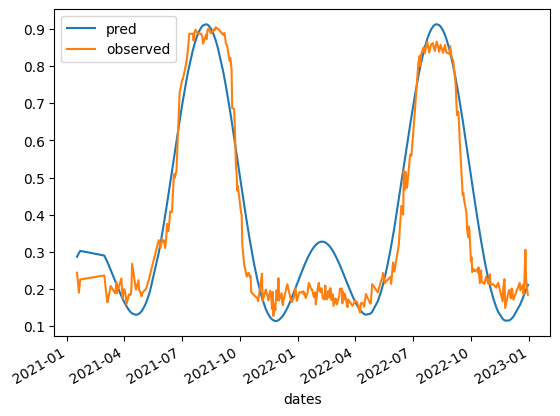

In [23]:
user_data = json.loads(vis.content.decode("utf-8"))
ndvi_values = pd.DataFrame(user_data)
ndvi_values["dates"] = pd.to_datetime(ndvi_values["dates"], utc=True)
ndvi_values.plot.line(x="dates")

<Axes: xlabel='dates'>

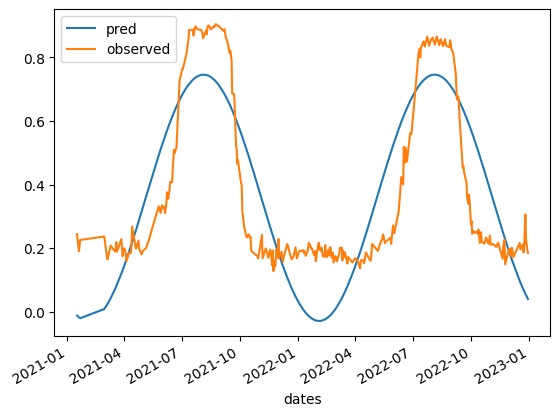

In [5]:
user_data = json.loads(vis.content.decode("utf-8"))
ndvi_values = pd.DataFrame(user_data)
ndvi_values["dates"] = pd.to_datetime(ndvi_values["dates"], utc=True)
ndvi_values.plot.line(x="dates")

<Axes: xlabel='dates'>

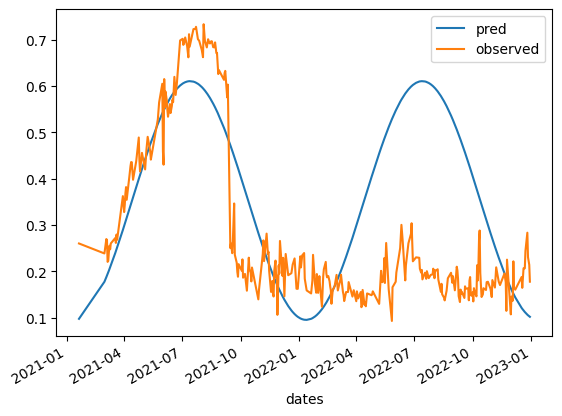

In [76]:
user_data = json.loads(vis.content.decode("utf-8"))
ndvi_values = pd.DataFrame(user_data)
ndvi_values["dates"] = pd.to_datetime(ndvi_values["dates"], utc=True)
ndvi_values.plot.line(x="dates")